In [29]:
# Bibliotecas

import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow as pa
import pyarrow.parquet as pq
from sklearn.linear_model import LinearRegression

## Painel Estatístico em Big Data

In [3]:
caminho_parquet  = 'pakistan_ecommerce_dataset_POLARS.parquet'

# Para fazer analise de venda bruta da tabela do ecommerce, primeiro precisamos pegar os pedidos que foram validados e realmente ocorreram.
status_validos = ['completed', 'paid', 'received']
inicial = (
    pl.scan_parquet(caminho_parquet).filter(
        (pl.col('status').is_in(status_validos)) &
        (pl.col('valor_venda_bruto') > 0)
    )
)

display(inicial.collect())



item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,discount_amount,payment_method,Working_Date,BI_Status,MV,Year,Month,Customer_Since,M-Y,FY,Customer_ID,valor_venda_bruto
i64,str,str,str,f64,i64,f64,i64,str,str,f64,str,str,str,str,i64,i64,str,str,str,i64,f64
211143,"""received""","""7/1/2016""","""BK1070200PL""",210.0,1,366.0,100147454,"""Soghaat""","""\N""",0.0,"""cod""","""7/1/2016""","""Valid""","""210""",2016,7,"""2016-7""","""7-2016""","""FY17""",10,210.0
211144,"""received""","""7/1/2016""","""BK1130200CF""",156.0,1,366.0,100147454,"""Soghaat""","""\N""",0.0,"""cod""","""7/1/2016""","""Valid""","""156""",2016,7,"""2016-7""","""7-2016""","""FY17""",10,156.0
211224,"""received""","""7/1/2016""","""kcc_krone deal""",360.0,1,360.0,100147504,"""Beauty & Grooming""","""C-MUX-106279""",0.0,"""cod""","""7/1/2016""","""Valid""","""360""",2016,7,"""2016-7""","""7-2016""","""FY17""",43,360.0
211226,"""received""","""7/1/2016""","""kcc_glamour deal""",320.0,1,320.0,100147506,"""Beauty & Grooming""","""C-MUX-106279""",0.0,"""cod""","""7/1/2016""","""Valid""","""320""",2016,7,"""2016-7""","""7-2016""","""FY17""",43,320.0
211229,"""received""","""7/1/2016""","""kcc_Buy 2 Frey Air Freshener &…",240.0,1,240.0,100147508,"""Beauty & Grooming""","""C-MUX-106279""",0.0,"""cod""","""7/1/2016""","""Valid""","""240""",2016,7,"""2016-7""","""7-2016""","""FY17""",43,240.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
905170,"""paid""","""8/28/2018""","""BAGPAR5AE95DB431B61""",520.0,2,1889.0,100562359,"""Beauty & Grooming""",null,0.0,"""Payaxis""","""8/28/2018""","""Valid""","""1.040""",2018,8,"""2017-11""","""8-2018""","""FY19""",67966,1040.0
905179,"""paid""","""8/28/2018""","""APPCHA5AF14939B8F8A""",44199.0,1,44499.0,100562365,"""Appliances""",null,0.0,"""Easypay""","""8/28/2018""","""Valid""","""44.199""",2018,8,"""2018-8""","""8-2018""","""FY19""",115323,44199.0
905192,"""paid""","""8/28/2018""","""MATINF59BAB39FDBEF1""",6760.0,1,7010.0,100562377,"""Mobiles & Tablets""",null,0.0,"""jazzwallet""","""8/28/2018""","""Valid""","""6.760""",2018,8,"""2016-9""","""8-2018""","""FY19""",8123,6760.0


### Métricas: Média, Mediana, Moda, Variância, Desvio Padrão, Amplitude

In [3]:
metricas1 = inicial.select([
    pl.col('valor_venda_bruto').mean().alias('Média'),
    pl.col('valor_venda_bruto').median().alias('Mediana'),
    pl.col('valor_venda_bruto').mode().alias('Moda'),
    pl.col('valor_venda_bruto').var().alias('Variância'),
    pl.col('valor_venda_bruto').std().alias('Desvio_Padrão'),
    (pl.col('valor_venda_bruto').max() - pl.col('valor_venda_bruto').min()).alias('Amplitude_Total')

]).collect()

print("\n--- Estatísticas Descritivas (Valor de venda bruto) ---")
display(metricas1)


--- Estatísticas Descritivas (Valor de venda bruto) ---


Média,Mediana,Moda,Variância,Desvio_Padrão,Amplitude_Total
f64,f64,f64,f64,f64,f64
3737.65923,695.0,999.0,1.4950e8,12227.203332,350096.6


### Forma e Posição: Assimetria, Curtose e Quartis

In [4]:
metricas2 = inicial.select([
    pl.col("valor_venda_bruto").quantile(0.25).alias("Q1"),
    pl.col("valor_venda_bruto").quantile(0.50).alias("Q2"),
    pl.col("valor_venda_bruto").quantile(0.75).alias("Q3"),
    pl.col("valor_venda_bruto").skew().alias("Assimetria"),
    pl.col("valor_venda_bruto").kurtosis().alias("Curtose")
]).collect()

print("\n--- Quartis e Forma da Distribuição ---")
display(metricas2)

# Análise rápida da Assimetria
assimetria = metricas2["Assimetria"][0]
print(f"\nInterpretação da Assimetria ({assimetria:.2f}):")
if -0.5 <= assimetria <= 0.5:
    print("-> Distribuição Simétrica (Dados bem balanceados)")
elif assimetria > 0.5:
    print("-> Assimétrica Positiva (Cauda para a direita - Existem valores muito altos puxando a média)")
else:
    print("-> Assimétrica Negativa (Cauda para a esquerda)")

# Analise curtose
curtose_excesso = metricas2['Curtose'][0]
curtose_real = curtose_excesso + 3

if curtose_real >= 2.5 and curtose_real <= 3.5:
    analise_curtose = "Mesocúrtica. Distribuição próxima da normal (dados uniformes no entorno da média)."
elif curtose_real < 2.5:
    analise_curtose = "Platicúrtica. Dados mais dispersos em relação à média. Caudas finas e Outliers comuns."
else: # curtose_real > 3.5
    analise_curtose = "Leptocúrtica. Dados extremamente concentrados no centro e caudas pesadas. Outliers muito comuns."
print(f"\nInterpretação da Curtose ({curtose_real:.2f}):\n-> {analise_curtose}")


--- Quartis e Forma da Distribuição ---


Q1,Q2,Q3,Assimetria,Curtose
f64,f64,f64,f64,f64
299.0,695.0,1875.0,9.566349,136.815725



Interpretação da Assimetria (9.57):
-> Assimétrica Positiva (Cauda para a direita - Existem valores muito altos puxando a média)

Interpretação da Curtose (139.82):
-> Leptocúrtica. Dados extremamente concentrados no centro e caudas pesadas. Outliers muito comuns.


### Outliers

In [5]:
# 1. Recuperar os valores de Q1 e Q3 calculados acima
Q1 = metricas2["Q1"][0]
Q3 = metricas2["Q3"][0]
IQR = Q3 - Q1

# 2. Definir limites
limite_inferior = Q1 - (1.5 * IQR)
limite_superior = Q3 + (1.5 * IQR)

print(f"\nLimites para Outliers: Inferior ({limite_inferior}) | Superior ({limite_superior})")


outliers = inicial.filter(
    (pl.col('valor_venda_bruto') < limite_inferior) |
    (pl.col('valor_venda_bruto') > limite_superior)
).select(['item_id', 'category_name_1', 'valor_venda_bruto'] ).collect()

print(f"Quantidade de pedidos considerados Outliers: {outliers.height}")
print("Exemplos de valores discrepantes:")
display(outliers.head())


Limites para Outliers: Inferior (-2065.0) | Superior (4239.0)
Quantidade de pedidos considerados Outliers: 11525
Exemplos de valores discrepantes:


item_id,category_name_1,valor_venda_bruto
i64,str,f64
229513,"""Appliances""",58000.0
230187,"""Mobiles & Tablets""",6900.0
235509,"""Mobiles & Tablets""",6900.0
235618,"""Kids & Baby""",4770.0
235619,"""Beauty & Grooming""",4446.0


### Visualização

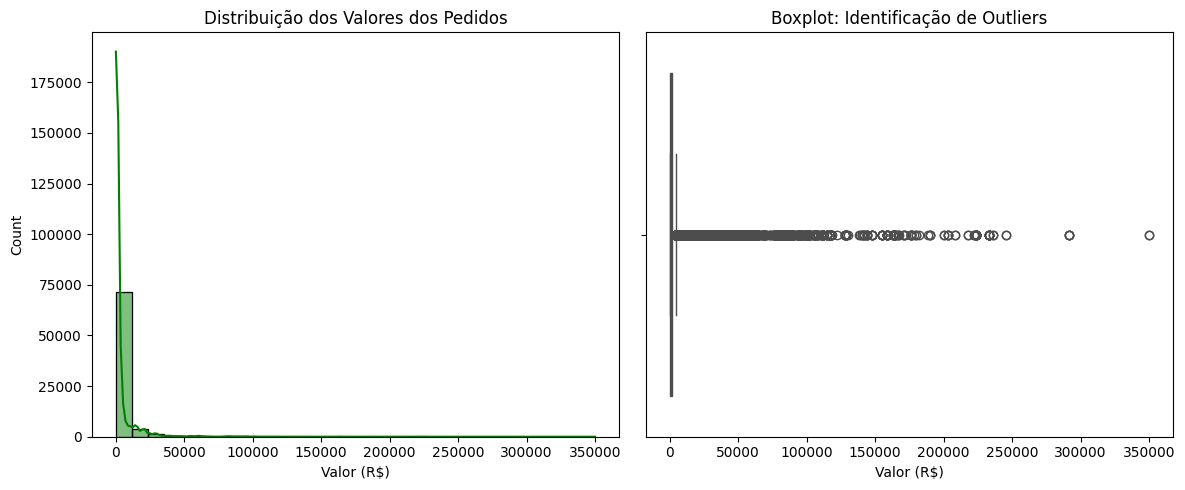

In [6]:
# Coletando a coluna para plotagem
visual = inicial.select("valor_venda_bruto").collect().to_series()

plt.figure(figsize=(12, 5))

# Histograma
plt.subplot(1, 2, 1)
sns.histplot(visual, bins=30, kde=True, color='green')
plt.title('Distribuição dos Valores dos Pedidos')
plt.xlabel('Valor (R$)')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=visual, color='orange')
plt.title('Boxplot: Identificação de Outliers')
plt.xlabel('Valor (R$)')

plt.tight_layout()
plt.show()

## Correlação de Pearson

**Pergunta de negócio:**  A categoria que mais vende é a que mais vai trazer valor de venda para o ecommerce?

In [7]:
df_pedidos = inicial.group_by("category_name_1").agg([
    pl.len().alias("Qtd_pedidos"), # variavel x
    pl.col('valor_venda_bruto').mean().alias('valor_venda_medio')
]).sort('Qtd_pedidos', descending=True).collect()

display(df_pedidos)
# 2. Calcular a Correlação de Pearson
correlacao = df_pedidos.select(
    pl.corr("Qtd_pedidos", 'valor_venda_medio', method='pearson').alias('r')
)

r= correlacao['r'][0]
r2 = r**2

print(f"\n--- Análise de Correlação por Categoria de produtos ---")
print(f"Coeficiente de Pearson (r): {r:.4f}")
print(f"Coeficiente de Determinação (r²): {r2:.4f}")

# Interpretação
if abs(r) < 0.3:
    print("Conclusão: Correlação FRACA. A quantidade de pedidos de uma categoria não influencia no valor médio de sua venda.")
elif abs(r) > 0.7:
    print("Conclusão: Correlação FORTE.")
else:
    print("Conclusão: Correlação MODERADA.")

category_name_1,Qtd_pedidos,valor_venda_medio
str,u32,f64
"""Men's Fashion""",12260,752.041793
"""Superstore""",10290,854.725663
"""Women's Fashion""",10146,1379.722226
"""Mobiles & Tablets""",8379,13436.850104
"""Beauty & Grooming""",6353,754.526477
…,…,…
"""Computing""",1437,6623.640431
"""School & Education""",571,395.976235
"""Books""",181,650.863536



--- Análise de Correlação por Categoria de produtos ---
Coeficiente de Pearson (r): 0.0023
Coeficiente de Determinação (r²): 0.0000
Conclusão: Correlação FRACA. A quantidade de pedidos de uma categoria não influencia no valor médio de sua venda.


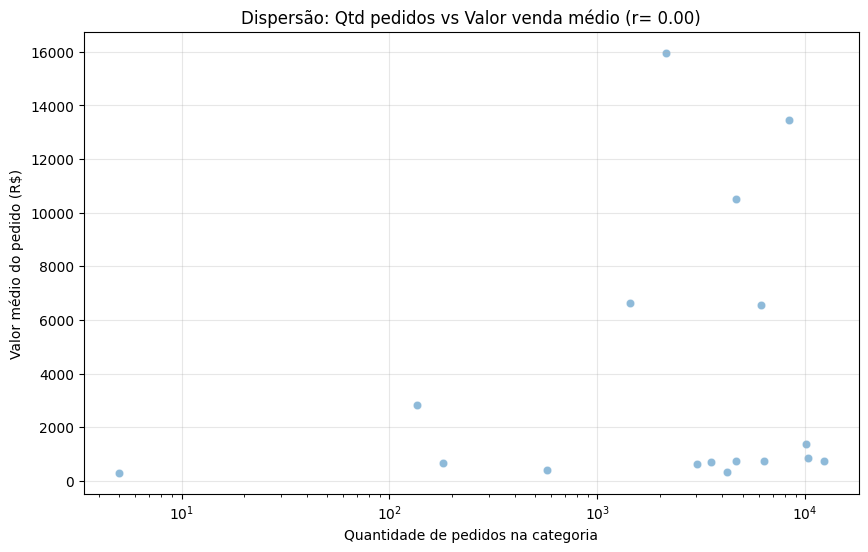

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data= df_pedidos.to_pandas(),
    x= 'Qtd_pedidos',
    y= 'valor_venda_medio',
    alpha=0.5
)

plt.title(f"Dispersão: Qtd pedidos vs Valor venda médio (r= {r:.2f})")
plt.xlabel('Quantidade de pedidos na categoria')
plt.ylabel('Valor médio do pedido (R$)')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.show()

### Regressão Linear

Dados para plotagem:
    DATA_REF  VALOR_MEDIO
0 2016-07-01   391.230769
1 2016-07-14  1509.400000
2 2016-07-15   990.000000
3 2016-07-19   468.000000
4 2016-07-25   150.000000


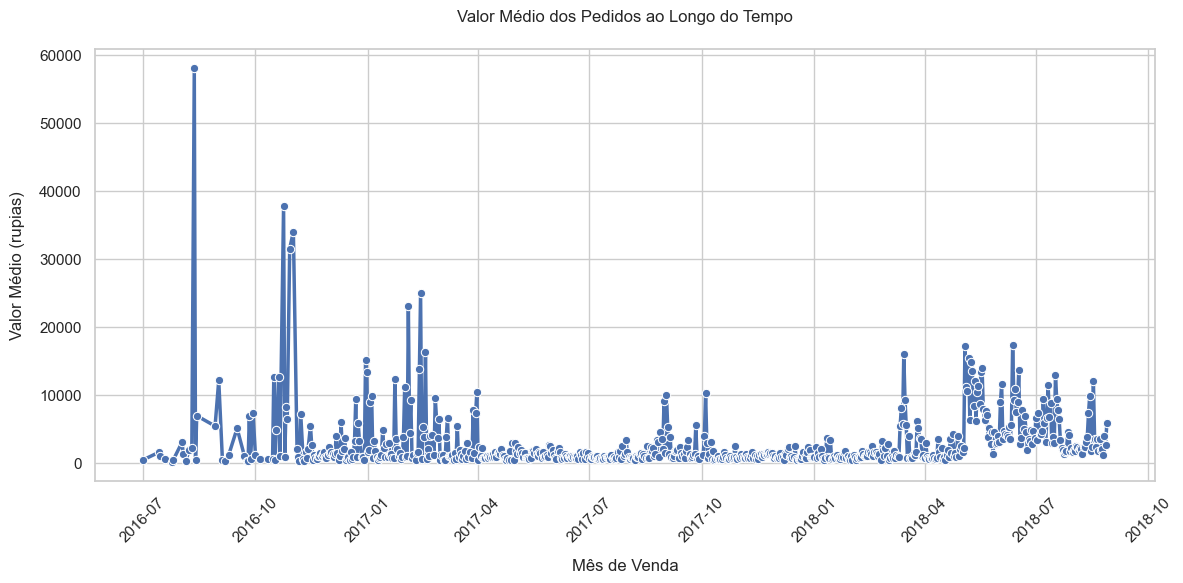

In [34]:
# Pegar a coluna created_at	(Transformar a string em data) - %m%d%Y e o valor médio de valor_venda_bruto em cada mês
df_data = inicial.with_columns([
    pl.col('created_at')
    .str.strptime(pl.Date, "%m/%d/%Y")
    .alias("DATA_REF")
])


df_agrupado = df_data.group_by("DATA_REF").agg(
    pl.col("valor_venda_bruto").mean().alias("VALOR_MEDIO")
).sort("DATA_REF").collect()

# Converter para Pandas explicitamente
df_plot = df_agrupado.to_pandas()

# Verificar os dados que serão plotados
print("Dados para plotagem:")
print(df_plot.head())

# Configurar o estilo do seaborn
sns.set_theme(style='whitegrid')

# Criar a figura e o eixo explicitamente
fig, ax = plt.subplots(figsize=(12,6))

# Plotar usando seaborn
sns.lineplot(
    data=df_plot,
    x="DATA_REF",
    y="VALOR_MEDIO",
    ax=ax,
    marker='o',
    linewidth=2.5
)

ax.set_title("Valor Médio dos Pedidos ao Longo do Tempo", pad=20)
ax.set_xlabel("Mês de Venda", labelpad=10),
ax.set_ylabel("Valor Médio (rupias)", labelpad=10)
ax.tick_params(axis='x', rotation=45)

# Ajustar layout para evitar cortes
plt.tight_layout()
plt.show()



In [27]:
# 1. Converter para tipo Date do Polars se necessário
if df_agrupado["DATA_REF"].dtype != pl.Date:
    df_agrupado = df_agrupado.with_columns(
        pl.col("DATA_REF").cast(pl.Date)
    )

# 2. Calcular usando expressões puras do Polars
df_reg = df_agrupado.with_columns(
    (pl.col("DATA_REF").dt.year() * 12 + pl.col("DATA_REF").dt.month() - 
     (pl.col("DATA_REF").min().dt.year() * 12 + pl.col("DATA_REF").min().dt.month()))
    .alias("MESES_DESDE_INICIO")
)

# 3. Verificar o resultado
print(df_reg.select(["DATA_REF", "MESES_DESDE_INICIO"]).head())

shape: (5, 2)
┌────────────┬────────────────────┐
│ DATA_REF   ┆ MESES_DESDE_INICIO │
│ ---        ┆ ---                │
│ date       ┆ i32                │
╞════════════╪════════════════════╡
│ 2016-07-01 ┆ 0                  │
│ 2016-07-14 ┆ 0                  │
│ 2016-07-15 ┆ 0                  │
│ 2016-07-19 ┆ 0                  │
│ 2016-07-25 ┆ 0                  │
└────────────┴────────────────────┘


Equação da reta: VALOR_MEDIO = 25.55 * MESES_DESDE_INICIO + 2385.56
Coeficiente angular (R$/mês): 25.55
Intercepto (valor inicial): R$ 2385.56

Métricas de avaliação:
Coeficiente de Determinação (R²): 0.0016
Erro Quadrático Médio (MSE): 19053375.88


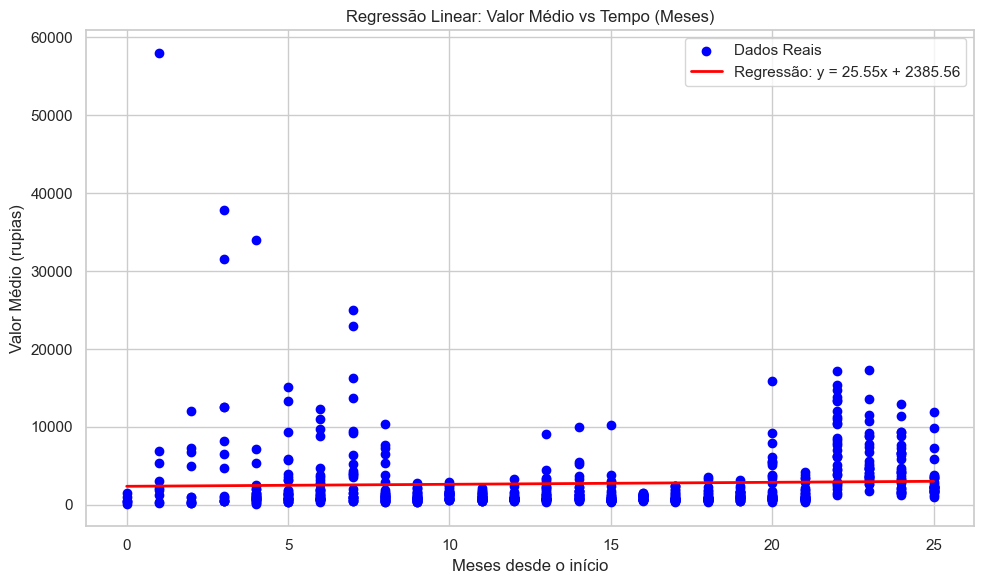

In [32]:
# y = subordinado 
# X = independente (o tempo não depende do valor para continuar passando)

# y = aX + b

## 1. Preparar os dados para o modelo
# Converter para arrays numpy
X = df_reg["MESES_DESDE_INICIO"].to_numpy().reshape(-1, 1)  # Variável independente (meses)
y = df_reg["VALOR_MEDIO"].to_numpy()                        # Variável dependente (valor)

## 2. Criar e treinar o modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Coeficientes do modelo
inclinacao = modelo.coef_[0] # a
intercepto = modelo.intercept_ # b

print(f"Equação da reta: VALOR_MEDIO = {inclinacao:.2f} * MESES_DESDE_INICIO + {intercepto:.2f}")
print(f"Coeficiente angular (R$/mês): {inclinacao:.2f}")
print(f"Intercepto (valor inicial): R$ {intercepto:.2f}")

## 3. Fazer previsões
y_pred = modelo.predict(X)

## 4. Avaliar o modelo
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

print(f"\nMétricas de avaliação:")
print(f"Coeficiente de Determinação (R²): {r2:.4f}")
print(f"Erro Quadrático Médio (MSE): {mse:.2f}")

## 5. Visualização dos resultados
plt.figure(figsize=(10, 6))

# Plotar dados reais
plt.scatter(X, y, color='blue', label='Dados Reais')

# Plotar linha de regressão
plt.plot(X, y_pred, color='red', linewidth=2, label=f'Regressão: y = {inclinacao:.2f}x + {intercepto:.2f}')

# Configurações do gráfico
plt.title('Regressão Linear: Valor Médio vs Tempo (Meses)')
plt.xlabel('Meses desde o início')
plt.ylabel('Valor Médio (rupias)')
plt.grid(True)
plt.legend()

# Mostrar gráfico
plt.tight_layout()
plt.show()

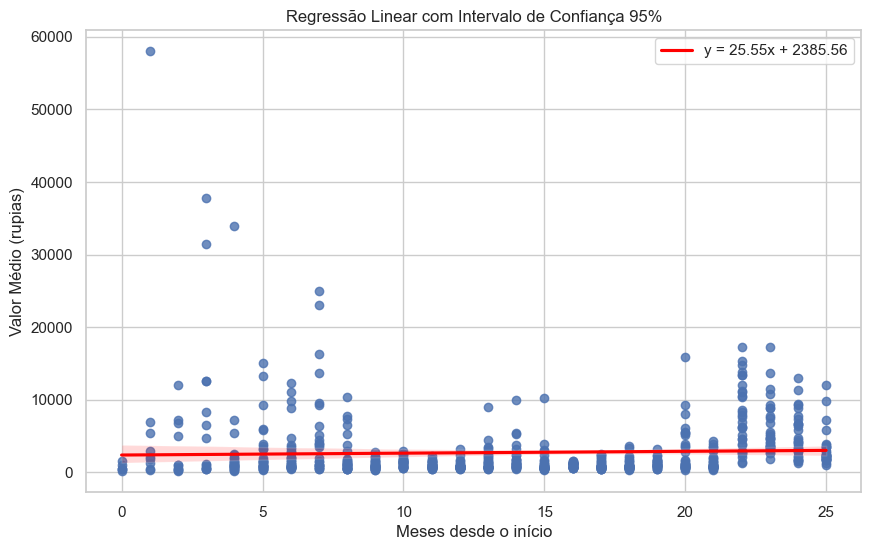

In [33]:
"""
Quanto mais próximos os pontos da linha, mais chances da previsão acontecer.
Como os pontos estão longes da linha, não da para prever.
"""

# Versão Alternativa com intervalo de confiança:
plt.figure(figsize=(10, 6))
sns.regplot(x=X.flatten(), y=y, ci=95, 
            line_kws={'color': 'red', 'label': f'y = {inclinacao:.2f}x + {intercepto:.2f}'})
plt.title('Regressão Linear com Intervalo de Confiança 95%')
plt.xlabel('Meses desde o início')
plt.ylabel('Valor Médio (rupias)')
plt.legend()
plt.grid(True)
plt.show()

**R² = 0.0016**, significa que a linha explica apenas 0.16% dos dados (ruim). Ou seja, não tem como prever qual será o valor médio dos pedidos pelo tempo. 

Fazer uma analise preditiva da venda de pedidos de uma categoria especifica ao longo dos meses.
